# Week 3 Lab — Linear Classification and the Perceptron


## Learning outcomes

By the end of the lab, you should be able to:

1. Distinguish binary classification from regression.
2. Explain class labels, linear scores, predictions, and decision boundaries.
3. Determine whether a dataset is linearly separable.
4. Explain and implement the perceptron learning algorithm.
5. Visualize a decision boundary on a two-feature dataset.
6. Compare a from-scratch implementation with scikit-learn's `Perceptron`.
7. Explain important limitations of linear classifiers.

## Recurring classification workflow

$$
\text{inspect} \rightarrow \text{choose }X,y \rightarrow \text{split}
\rightarrow \text{fit} \rightarrow \text{predict} \rightarrow
\text{evaluate} \rightarrow \text{diagnose}
$$

- **Features $X$:** information used to make predictions.
- **Target $y$:** the class to predict.
- **Training set:** used to learn the model parameters.
- **Test set:** held out from fitting and used to estimate generalization.
- **Prediction:** the class assigned by the fitted model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from sklearn.datasets import (
    load_breast_cancer,
    load_iris,
    make_blobs,
    make_moons,
)
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.set_printoptions(precision=3, suppress=True)

print("Environment ready")

Environment ready


## 1. Binary classification

In regression, the target is a numerical quantity. In binary classification, the target contains two classes—for example, spam/not-spam, pass/fail, or $-1/+1$.

A linear classifier calculates a score:

$$
s(\mathbf{x})=\mathbf{w}^{T}\mathbf{x}+b.
$$

For labels $-1$ and $+1$, we can convert this score into a prediction:

$$
\hat y=
\begin{cases}
+1, & s(\mathbf{x})\geq0,\\
-1, & s(\mathbf{x})<0.
\end{cases}
$$

The score is not a probability. It can be any real number. Its sign determines the predicted class.

In [ ]:
X_small = np.array([
    [1.0, 1.0],
    [2.0, 0.5],
    [-1.0, -1.5],
])

w_demo = np.array([1.2, 0.8])
b_demo = -1.0

scores = X_small @ w_demo + b_demo
predicted_classes = np.where(scores >= 0, 1, -1)

pd.DataFrame({
    "x1": X_small[:, 0],
    "x2": X_small[:, 1],
    "score": scores,
    "predicted_class": predicted_classes,
})

,x1,x2,score,predicted_class
0,1.0,1.0,1.0,1
1,2.0,0.5,1.8,1
2,-1.0,-1.5,-3.4,-1


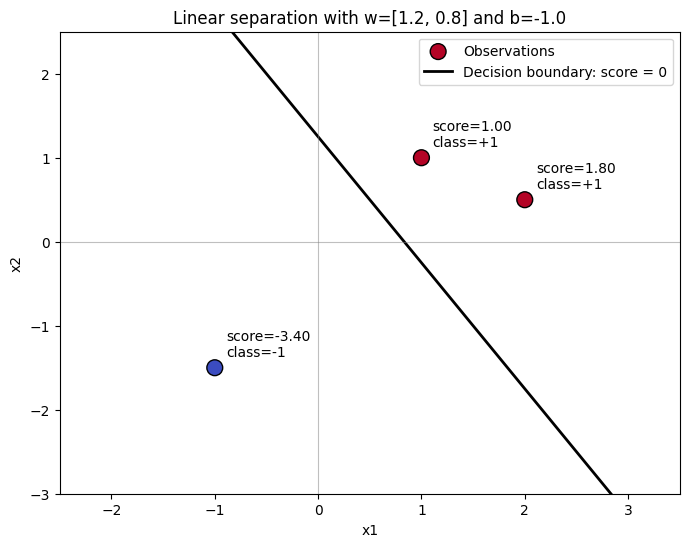

In [ ]:
def plot_score_boundary(X, w, b):
    scores = X @ w + b
    predicted_classes = np.where(scores >= 0, 1, -1)

    # Choose plotting limits with enough space around the observations.
    x1_min, x1_max = X[:, 0].min() - 1.5, X[:, 0].max() + 1.5
    x2_min, x2_max = X[:, 1].min() - 1.5, X[:, 1].max() + 1.5

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=predicted_classes,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        s=130,
        edgecolor="black",
        label="Observations",
    )

    # The boundary satisfies w1*x1 + w2*x2 + b = 0.
    if not np.isclose(w[1], 0):
        x1_line = np.linspace(x1_min, x1_max, 300)
        x2_line = -(w[0] * x1_line + b) / w[1]
        plt.plot(x1_line, x2_line, color="black", linewidth=2,
                 label="Decision boundary: score = 0")
    elif not np.isclose(w[0], 0):
        # If w2 is zero, the boundary is vertical.
        plt.axvline(-b / w[0], color="black", linewidth=2,
                    label="Decision boundary: score = 0")

    for i, (x1, x2) in enumerate(X):
        plt.annotate(
            f"score={scores[i]:.2f}\nclass={predicted_classes[i]:+d}",
            (x1, x2),
            xytext=(8, 8),
            textcoords="offset points",
        )

    plt.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
    plt.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
    plt.xlim(x1_min, x1_max)
    plt.ylim(x2_min, x2_max)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Linear separation with w={w.tolist()} and b={b}")
    plt.legend()
    plt.show()


plot_score_boundary(X_small, w_demo, b_demo)



1. What class is assigned when the score is exactly zero?
2. What happens to the scores if only $b$ changes?
3. If $\mathbf{w}$ and $b$ are both multiplied by a positive number, do the predicted classes change?
4. Why is the score not a probability?

## 2. Linear separability

A dataset is **linearly separable** if a straight line in two dimensions—or a hyperplane in higher dimensions—can separate the classes without mistakes.

### Separators in different dimensions

The same linear-score equation applies in every dimension:

$$
\mathbf{w}^{T}\mathbf{x}+b=0.
$$

What the boundary looks like depends on the number of input features:

| Number of features | Location of observations | Linear decision boundary |
|---:|---|---|
| 1 | number line | a point/threshold |
| 2 | plane | a line |
| 3 | three-dimensional space | a plane |
| $d$ | $d$-dimensional space | a $(d-1)$-dimensional hyperplane |

The next cells show one-, two-, and three-dimensional examples. The separator always has one dimension fewer than the feature space.

#### 1D: a threshold point

With one feature, the score is $s(x)=wx+b$. The boundary satisfies

$$
wx+b=0 \quad\Rightarrow\quad x=-\frac{b}{w}.
$$

Everything to one side of the threshold receives one class, and everything on the other side receives the other class.

Try changing `b_1d`. The threshold moves because $-b/w$ changes. Try changing the sign of `w_1d`: the class assigned to each side reverses.

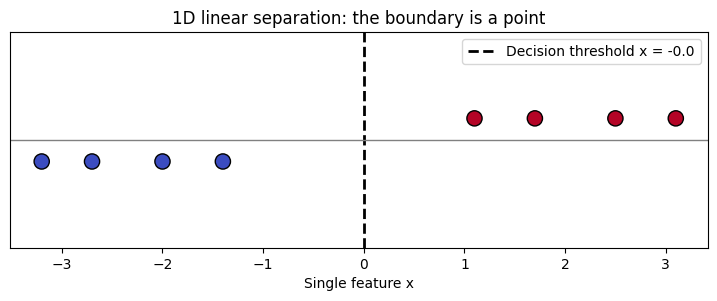

In [ ]:
# One-dimensional observations.
x_1d = np.array([-3.2, -2.7, -2.0, -1.4, 1.1, 1.7, 2.5, 3.1])
y_1d = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

w_1d = 1.0
b_1d = 0.0
threshold_1d = -b_1d / w_1d

# A small vertical offset lets both classes remain visible on a number line.
y_position = np.where(y_1d == -1, -0.04, 0.04)

plt.figure(figsize=(9, 2.8))
plt.scatter(
    x_1d,
    y_position,
    c=y_1d,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    s=120,
    edgecolor="black",
)
plt.axvline(
    threshold_1d,
    color="black",
    linewidth=2,
    linestyle="--",
    label=f"Decision threshold x = {threshold_1d:.1f}",
)
plt.axhline(0, color="gray", linewidth=1)
plt.yticks([])
plt.xlabel("Single feature x")
plt.title("1D linear separation: the boundary is a point")
plt.ylim(-0.2, 0.2)
plt.legend()
plt.show()

#### 2D: a separating line

With two features, the score is

$$
s(\mathbf{x})=w_1x_1+w_2x_2+b.
$$

The decision boundary satisfies

$$
w_1x_1+w_2x_2+b=0.
$$

Solving for $x_2$ lets us draw the boundary as a line:

$$
x_2=-\frac{w_1x_1+b}{w_2}.
$$

Points on opposite sides of the line receive different classes. The following synthetic dataset lets us see the geometry clearly; later, a perceptron will learn a boundary from real Iris data.

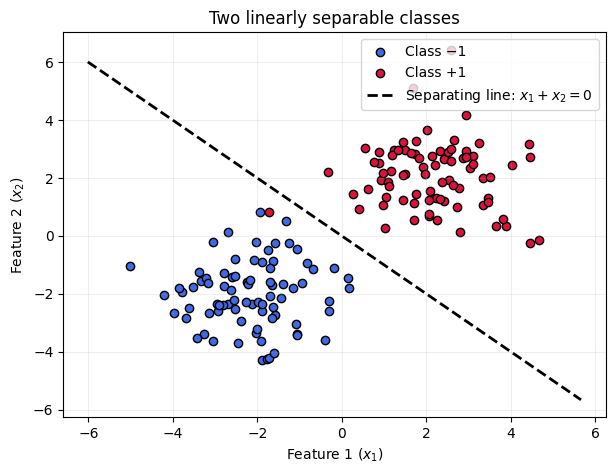

Feature-matrix shape: (160, 2)
Class counts: (array([-1,  1]), array([80, 80]))


In [ ]:
X_blobs, y_blobs_zero_one = make_blobs(
    n_samples=160,
    centers=[(-2, -2), (2, 2)],
    cluster_std=1.15,
    random_state=RANDOM_STATE,
)

# Convert labels from 0/1 to -1/+1
y_blobs = np.where(y_blobs_zero_one == 0, -1, 1)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_blobs[y_blobs == -1, 0],
    X_blobs[y_blobs == -1, 1],
    color="royalblue",
    edgecolor="black",
    label="Class −1",
)

plt.scatter(
    X_blobs[y_blobs == 1, 0],
    X_blobs[y_blobs == 1, 1],
    color="crimson",
    edgecolor="black",
    label="Class +1",
)

# Decision boundary: x1 + x2 = 0, or x2 = -x1
x1_values = np.linspace(
    X_blobs[:, 0].min() - 1,
    X_blobs[:, 0].max() + 1,
    200,
)

x2_values = -x1_values

plt.plot(
    x1_values,
    x2_values,
    color="black",
    linestyle="--",
    linewidth=2,
    label=r"Separating line: $x_1+x_2=0$",
)

plt.xlabel("Feature 1 ($x_1$)")
plt.ylabel("Feature 2 ($x_2$)")
plt.title("Two linearly separable classes")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

print("Feature-matrix shape:", X_blobs.shape)
print(
    "Class counts:",
    np.unique(y_blobs, return_counts=True)
)

#### 3D: a separating plane

With three features, the boundary satisfies

$$
w_1x_1+w_2x_2+w_3x_3+b=0.
$$

Solving for $x_3$ lets us draw the boundary as a plane:

$$
x_3=-\frac{w_1x_1+w_2x_2+b}{w_3}.
$$

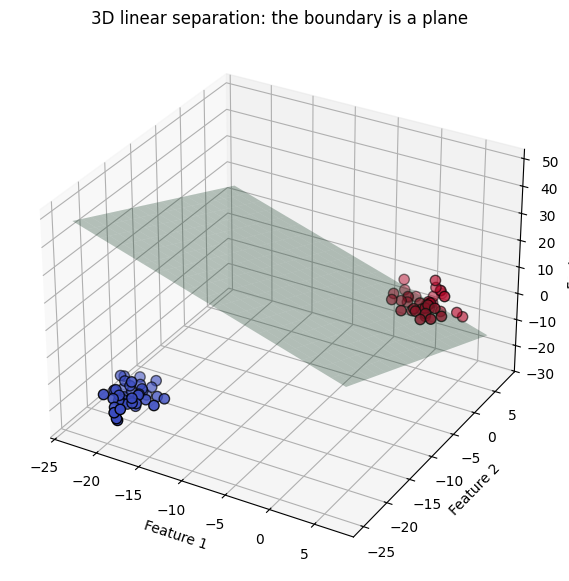

In [ ]:
# Three-dimensional observations generated around two centers.
X_3d, y_3d_zero_one = make_blobs(
    n_samples=80,
    centers=[(-20, -20, -20), (2, 2, 2)],
    cluster_std=1.9,
    random_state=RANDOM_STATE,
)
y_3d = np.where(y_3d_zero_one == 0, -1, 1)

# A known plane between the two generated groups.
w_3d = np.array([1.0, 1.0, 1.0])
b_3d = 0.0

x1_plane, x2_plane = np.meshgrid(
    np.linspace(X_3d[:, 0].min() - 1, X_3d[:, 0].max() + 1, 20),
    np.linspace(X_3d[:, 1].min() - 1, X_3d[:, 1].max() + 1, 20),
)
x3_plane = -(
    w_3d[0] * x1_plane + w_3d[1] * x2_plane + b_3d
) / w_3d[2]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X_3d[:, 0],
    X_3d[:, 1],
    X_3d[:, 2],
    c=y_3d,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    s=55,
    edgecolor="black",
)
ax.plot_surface(
    x1_plane,
    x2_plane,
    x3_plane,
    color="seagreen",
    alpha=0.30,
    edgecolor="none",
)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
ax.set_title("3D linear separation: the boundary is a plane")
plt.show()

**Questions:**

1. Why is the 1D boundary a point rather than a line?
2. Why is the 2D boundary a line rather than an area?
3. Why is the 3D boundary a plane rather than a solid region?
4. What does the weight vector control geometrically?
5. What does the intercept control?
6. Can we directly visualize a hyperplane when there are 30 features? What can we use instead to evaluate the classifier?

## 3. Train/test split: moving to a real dataset

The synthetic examples above demonstrate the geometry of linear separators. For training and evaluation, we now use a binary version of the Iris dataset:

- **Class $+1$:** setosa
- **Class $-1$:** not setosa
- **Features:** sepal length and sepal width


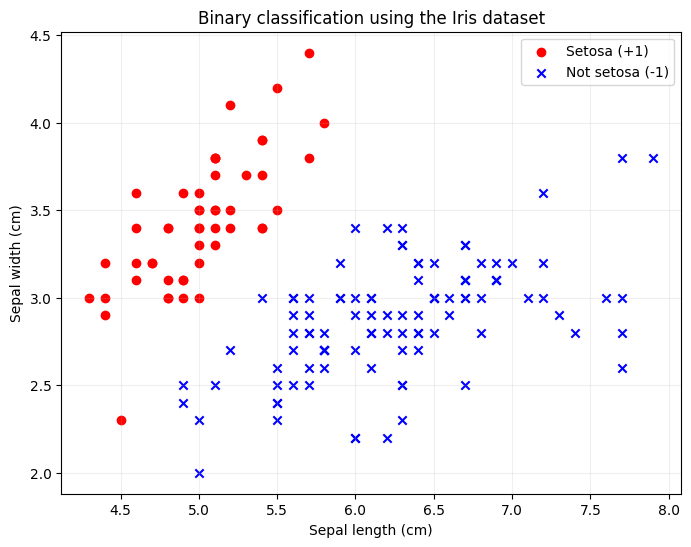

Feature-matrix shape: (150, 2)
Class counts: (array([-1,  1]), array([100,  50]))


In [ ]:
iris = load_iris()

# Use sepal length and sepal width so the data remain visualizable.
X_iris = iris.data[:, :2]

# Setosa = +1; versicolor or virginica = -1.
y_iris = np.where(iris.target == 0, 1, -1)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_iris[y_iris == 1, 0],
    X_iris[y_iris == 1, 1],
    color="red",
    marker="o",
    label="Setosa (+1)",
)
plt.scatter(
    X_iris[y_iris == -1, 0],
    X_iris[y_iris == -1, 1],
    color="blue",
    marker="x",
    label="Not setosa (-1)",
)
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Binary classification using the Iris dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Feature-matrix shape:", X_iris.shape)
print("Class counts:", np.unique(y_iris, return_counts=True))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_iris
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training classes:", np.unique(y_train, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

Training shape: (112, 2)
Test shape: (38, 2)
Training classes: (array([-1,  1]), array([75, 37]))
Test classes: (array([-1,  1]), array([25, 13]))


## 4. Scikit-learn's perceptron

Important arguments:

- `max_iter`: maximum number of passes through the training data;
- `tol`: stopping tolerance;
- `eta0`: learning rate controlling the update size;
- `random_state`: makes the training order reproducible.

The model must be fitted using only the training subset.

In [ ]:
sk_perceptron = Perceptron(
    max_iter=1000,
    tol=1e-3,
    eta0=0.1,
    random_state=RANDOM_STATE,
)

sk_perceptron.fit(X_train, y_train)
sk_predictions = sk_perceptron.predict(X_test)

print("Intercept:", sk_perceptron.intercept_)
print("Weights:", sk_perceptron.coef_)
print("Epochs used:", sk_perceptron.n_iter_)

Intercept: [0.1]
Weights: [[-0.67  1.12]]
Epochs used: 7


## 5. Classification evaluation

Accuracy is the proportion of correct predictions:

$$
\text{accuracy}=\frac{\text{number of correct predictions}}
{\text{total number of predictions}}.
$$

A confusion matrix provides more detail. Rows represent true classes and columns represent predicted classes. Correct predictions appear on the main diagonal; errors appear off the diagonal.

Test accuracy: 0.974


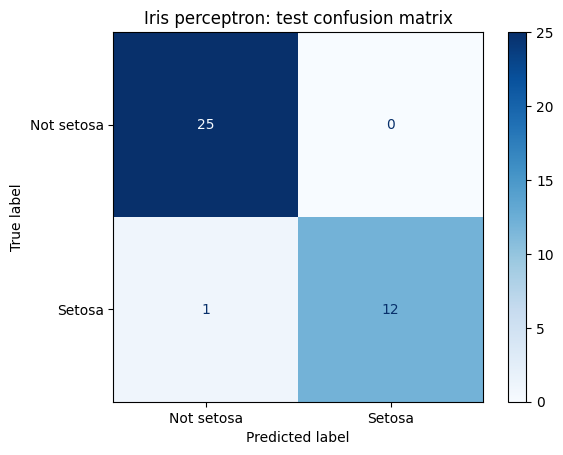

In [ ]:
sk_accuracy = accuracy_score(y_test, sk_predictions)
print(f"Test accuracy: {sk_accuracy:.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    sk_predictions,
    labels=[-1, 1],
    display_labels=["Not setosa", "Setosa"],
    cmap="Blues",
)
plt.title("Iris perceptron: test confusion matrix")
plt.show()

Accuracy alone can be misleading for imbalanced data. If 99% of observations belong to one class, always predicting that class gives 99% accuracy while completely failing on the minority class. Always inspect class counts and the confusion matrix.

## 6. Decision boundary

The decision boundary contains the points whose score is zero:

$$
w_1x_1+w_2x_2+b=0.
$$

For two features, solve for $x_2$:

$$
x_2=-\frac{w_1x_1+b}{w_2}.
$$

Changing the intercept translates the line. Changing the weights can rotate it. Points on opposite sides receive different predicted classes.

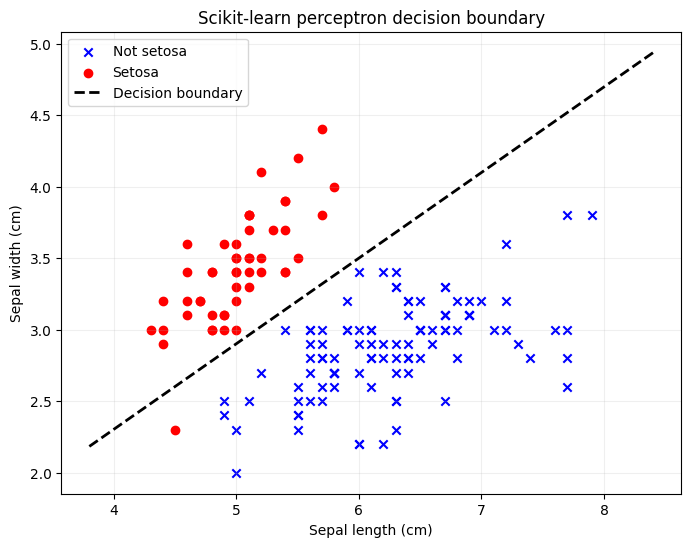

In [ ]:
def plot_linear_boundary(
    model,
    X,
    y,
    title,
    class_names=("Class -1", "Class +1"),
    x_label="Feature 1",
    y_label="Feature 2",
):
    w1, w2 = model.coef_[0]
    b = model.intercept_[0]

    x1_values = np.linspace(
        X[:, 0].min() - 0.5,
        X[:, 0].max() + 0.5,
        200,
    )

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        color="blue",
        marker="x",
        label=class_names[0],
    )
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        color="red",
        marker="o",
        label=class_names[1],
    )

    if not np.isclose(w2, 0):
        x2_values = -(w1 * x1_values + b) / w2
        plt.plot(
            x1_values,
            x2_values,
            color="black",
            linestyle="--",
            linewidth=2,
            label="Decision boundary",
        )
    elif not np.isclose(w1, 0):
        plt.axvline(
            -b / w1,
            color="black",
            linestyle="--",
            linewidth=2,
            label="Decision boundary",
        )

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


# The model was fitted only on X_train. We show all Iris observations here
# only to make the learned boundary easier to inspect.
plot_linear_boundary(
    sk_perceptron,
    X_iris,
    y_iris,
    "Scikit-learn perceptron decision boundary",
    class_names=("Not setosa", "Setosa"),
    x_label="Sepal length (cm)",
    y_label="Sepal width (cm)",
)

## 7. Perceptron learning algorithm

For every training observation $(\mathbf{x}_i,y_i)$:

1. Calculate $s_i=\mathbf{w}^T\mathbf{x}_i+b$.
2. Check the signed score $y_i s_i$.
3. If $y_i s_i\leq0$, the observation is misclassified or lies on the boundary, so update:

$$
\mathbf{w}\leftarrow\mathbf{w}+\eta y_i\mathbf{x}_i,
$$

$$
b\leftarrow b+\eta y_i.
$$

The update moves the score of that observation toward the correct side of the boundary. It is a **mistake-driven perceptron update**; it can be interpreted as a stochastic subgradient step on perceptron loss.



In [ ]:
iris_scaler = StandardScaler()

# Fit the scaler only on training data
X_train_scaled = iris_scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = iris_scaler.transform(X_test)

learning_rate = 0.1
maximum_epochs = 50

w = np.zeros(X_train_scaled.shape[1])
b = 0.0

rng = np.random.default_rng(RANDOM_STATE)

epoch_history = []
update_history = []

for epoch in range(maximum_epochs):
    mistakes = 0

    # Shuffle observations at the beginning of each epoch.
    indices = rng.permutation(len(X_train_scaled))

    for index in indices:
        xi = X_train_scaled[index]
        yi = y_train[index]

        score = np.dot(w, xi) + b

        if yi * score <= 0:
            w_before = w.copy()
            b_before = b

            w = w + learning_rate * yi * xi
            b = b + learning_rate * yi
            mistakes += 1

            update_history.append({
                "epoch": epoch + 1,
                "observation": index,
                "w_before": w_before,
                "b_before": b_before,
                "w_after": w.copy(),
                "b_after": b,
            })

    epoch_history.append({
        "epoch": epoch + 1,
        "weights": w.copy(),
        "intercept": b,
        "mistakes": mistakes,
    })

    print(
        f"Epoch {epoch + 1}: mistakes={mistakes}, "
        f"w={np.round(w, 3)}, b={b:.3f}"
    )

    if mistakes == 0:
        print(f"\nConverged after {epoch + 1} epochs.")
        break

Epoch 1: mistakes=8, w=[-0.221  0.247], b=-0.200
Epoch 2: mistakes=0, w=[-0.221  0.247], b=-0.200

Converged after 2 epochs.


In [ ]:
def boundary_in_original_units(w, b, x_values, scaler):
    """
    Convert a boundary learned from standardized features
    back into the original feature units.
    """

    w_original = w / scaler.scale_

    b_original = b - np.sum(
        w * scaler.mean_ / scaler.scale_
    )

    if abs(w_original[1]) < 1e-10:
        return None, -b_original / w_original[0]

    y_values = -(
        w_original[0] * x_values + b_original
    ) / w_original[1]

    return y_values, None

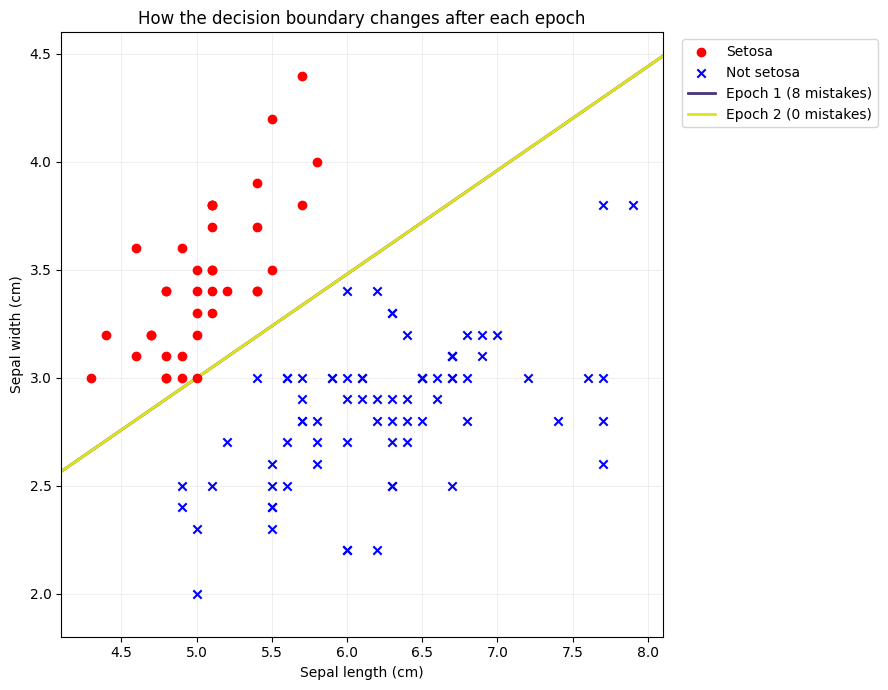

In [ ]:
x_values = np.linspace(
    X_train[:, 0].min() - 0.3,
    X_train[:, 0].max() + 0.3,
    300
)

plt.figure(figsize=(9, 7))

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    color="red",
    marker="o",
    label="Setosa",
    zorder=3
)

plt.scatter(
    X_train[y_train == -1, 0],
    X_train[y_train == -1, 1],
    color="blue",
    marker="x",
    label="Not setosa",
    zorder=3
)

colors = plt.cm.viridis(
    np.linspace(0.15, 0.95, len(epoch_history))
)

for color, state in zip(colors, epoch_history):
    y_values, vertical_x = boundary_in_original_units(
        state["weights"],
        state["intercept"],
        x_values,
        iris_scaler
    )

    label = (
        f"Epoch {state['epoch']} "
        f"({state['mistakes']} mistakes)"
    )

    if y_values is not None:
        plt.plot(
            x_values,
            y_values,
            color=color,
            linewidth=2,
            label=label
        )
    else:
        plt.axvline(
            vertical_x,
            color=color,
            linewidth=2,
            label=label
        )

plt.xlim(4.1, 8.1)
plt.ylim(1.8, 4.6)
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("How the decision boundary changes after each epoch")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(8, 6))

def draw_boundary(ax, w, b, color, linestyle, label):
    y_values, vertical_x = boundary_in_original_units(
        w,
        b,
        x_values,
        iris_scaler
    )

    if y_values is not None:
        ax.plot(
            x_values,
            y_values,
            color=color,
            linestyle=linestyle,
            linewidth=2,
            label=label
        )
    else:
        ax.axvline(
            vertical_x,
            color=color,
            linestyle=linestyle,
            linewidth=2,
            label=label
        )


def animate_update(frame):
    ax.clear()

    state = update_history[frame]
    updated_index = state["observation"]

    ax.scatter(
        X_train[y_train == 1, 0],
        X_train[y_train == 1, 1],
        color="red",
        marker="o",
        label="Setosa"
    )

    ax.scatter(
        X_train[y_train == -1, 0],
        X_train[y_train == -1, 1],
        color="blue",
        marker="x",
        label="Not setosa"
    )

    # Highlight the point responsible for this update
    ax.scatter(
        X_train[updated_index, 0],
        X_train[updated_index, 1],
        s=220,
        facecolors="none",
        edgecolors="gold",
        linewidths=4,
        label="Point causing update",
        zorder=5
    )

    # Boundary before the update
    if np.linalg.norm(state["w_before"]) > 0:
        draw_boundary(
            ax,
            state["w_before"],
            state["b_before"],
            color="gray",
            linestyle="--",
            label="Before update"
        )

    # Boundary after the update
    draw_boundary(
        ax,
        state["w_after"],
        state["b_after"],
        color="green",
        linestyle="-",
        label="After update"
    )

    ax.set_xlim(4.1, 8.1)
    ax.set_ylim(1.8, 4.6)
    ax.set_xlabel("Sepal length (cm)")
    ax.set_ylabel("Sepal width (cm)")
    ax.set_title(
        f"Epoch {state['epoch']} — "
        f"parameter update {frame + 1}/{len(update_history)}"
    )
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right")


animation = FuncAnimation(
    fig,
    animate_update,
    frames=len(update_history),
    interval=1000,
    repeat=True
)

plt.close(fig)

HTML(animation.to_jshtml())

## 8. Perceptron from scratch

An **epoch** is one complete pass through the training data. The implementation below trains only on `X_train` and `y_train`, records the number of parameter updates in every epoch, and stops when an epoch finishes with no mistakes.


In [ ]:
def train_perceptron_from_scratch(
    X,
    y,
    learning_rate=0.1,
    epochs=20,
):
    w = np.zeros(X.shape[1])
    b = 0.0
    mistakes_per_epoch = []

    for epoch in range(epochs):
        epoch_mistakes = 0

        for xi, yi in zip(X, y):
            score = np.dot(w, xi) + b

            if yi * score <= 0:
                w = w + learning_rate * yi * xi
                b = b + learning_rate * yi
                epoch_mistakes += 1

        mistakes_per_epoch.append(epoch_mistakes)

        if epoch_mistakes == 0:
            break

    return w, b, np.array(mistakes_per_epoch)


def predict_perceptron_from_scratch(X, w, b):
    scores = X @ w + b
    return np.where(scores >= 0, 1, -1)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


w_scratch, b_scratch, mistake_history = (
    train_perceptron_from_scratch(
        X_train_scaled,
        y_train,
        learning_rate=0.1,
        epochs=20,
    )
)

scratch_predictions = predict_perceptron_from_scratch(
    X_test_scaled,
    w_scratch,
    b_scratch,
)

scratch_accuracy = accuracy_score(
    y_test,
    scratch_predictions
)

print("Scratch weights:", np.round(w_scratch, 3))
print("Scratch intercept:", round(b_scratch, 3))
print("Scratch test accuracy:", round(scratch_accuracy, 3))
print("Number of epochs completed:", len(mistake_history))

Scratch weights: [-0.141  0.078]
Scratch intercept: -0.1
Scratch test accuracy: 0.974
Number of epochs completed: 2


In [ ]:
sk_perceptron_scaled = Perceptron(
    max_iter=1000,
    tol=1e-3,
    eta0=0.1,
    random_state=RANDOM_STATE,
)

sk_perceptron_scaled.fit(
    X_train_scaled,
    y_train
)

sk_predictions_scaled = sk_perceptron_scaled.predict(
    X_test_scaled
)

sk_accuracy_scaled = accuracy_score(
    y_test,
    sk_predictions_scaled
)

print("Scikit-learn weights:", sk_perceptron_scaled.coef_[0])
print("Scikit-learn intercept:", sk_perceptron_scaled.intercept_[0])
print("Scikit-learn epochs:", sk_perceptron_scaled.n_iter_)
print("Scikit-learn test accuracy:", round(sk_accuracy_scaled, 3))

Scikit-learn weights: [-0.233  0.202]
Scikit-learn intercept: -0.2
Scikit-learn epochs: 7
Scikit-learn test accuracy: 0.974


In [ ]:
comparison = pd.DataFrame({
    "Implementation": [
        "From scratch",
        "Scikit-learn"
    ],
    "Test accuracy": [
        scratch_accuracy,
        sk_accuracy_scaled
    ]
})

comparison

,Implementation,Test accuracy
0,From scratch,0.973684
1,Scikit-learn,0.973684


The scratch and scikit-learn implementations do not need identical coefficients. Training order, stopping rules, and implementation details can lead to different separating boundaries. Multiple boundaries may also classify separable data correctly. The important comparison is whether both implement the same learning principle and generalize successfully.

## 9. Limitation of a linear classifier

The perceptron convergence theorem requires linearly separable data. If no separating hyperplane exists, the algorithm can continue making updates without reaching zero training mistakes.

The following two-moons dataset has a curved class structure.

Moon test accuracy: 0.84


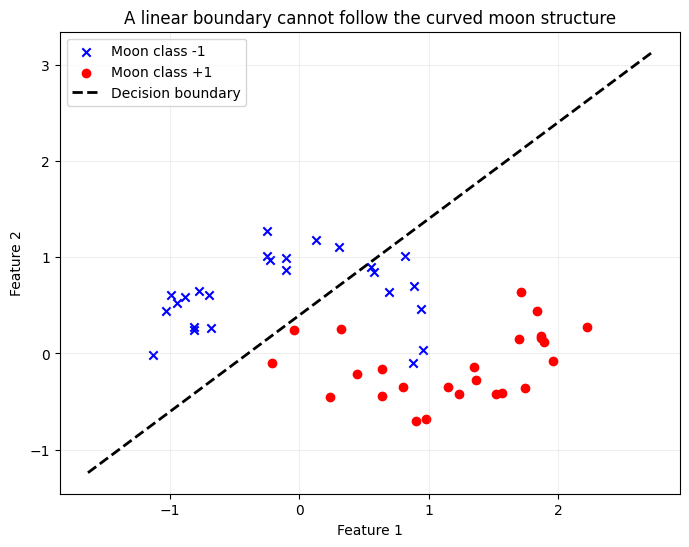

In [ ]:
X_moons, y_moons_zero_one = make_moons(
    n_samples=200,
    noise=0.15,
    random_state=RANDOM_STATE,
)
y_moons = np.where(y_moons_zero_one == 0, -1, 1)

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_moons,
)

moon_model = Perceptron(
    max_iter=1000,
    tol=1e-3,
    eta0=0.1,
    random_state=RANDOM_STATE,
)
moon_model.fit(Xm_train, ym_train)
moon_predictions = moon_model.predict(Xm_test)

print("Moon test accuracy:", accuracy_score(ym_test, moon_predictions))
plot_linear_boundary(
    moon_model,
    Xm_test,
    ym_test,
    "A linear boundary cannot follow the curved moon structure",
    class_names=("Moon class -1", "Moon class +1"),
    x_label="Feature 1",
    y_label="Feature 2",
)

##Changing the feature basis


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_moon_model = make_pipeline(
    PolynomialFeatures(
        degree=3,
        include_bias=False
    ),
    StandardScaler(),
    Perceptron(
        max_iter=5000,
        tol=1e-4,
        eta0=0.1,
        random_state=RANDOM_STATE,
    ),
)

polynomial_moon_model.fit(
    Xm_train,
    ym_train
)

polynomial_predictions = polynomial_moon_model.predict(
    Xm_test
)

polynomial_accuracy = accuracy_score(
    ym_test,
    polynomial_predictions
)

print(
    "Linear perceptron accuracy:",
    round(accuracy_score(ym_test, moon_predictions), 3)
)

print(
    "Polynomial-basis perceptron accuracy:",
    round(polynomial_accuracy, 3)
)

Linear perceptron accuracy: 0.84
Polynomial-basis perceptron accuracy: 0.98


In [ ]:
def plot_classifier_regions(
    model,
    X,
    y,
    title,
    ax,
    class_names=("Class −1", "Class +1"),
):
    x1_min = X[:, 0].min() - 0.5
    x1_max = X[:, 0].max() + 0.5
    x2_min = X[:, 1].min() - 0.5
    x2_max = X[:, 1].max() + 0.5

    x1_grid, x2_grid = np.meshgrid(
        np.linspace(x1_min, x1_max, 400),
        np.linspace(x2_min, x2_max, 400)
    )

    grid_points = np.column_stack([
        x1_grid.ravel(),
        x2_grid.ravel()
    ])

    grid_predictions = model.predict(
        grid_points
    ).reshape(x1_grid.shape)

    # Shade the two prediction regions
    ax.contourf(
        x1_grid,
        x2_grid,
        grid_predictions,
        levels=[-1.5, 0, 1.5],
        cmap="coolwarm",
        alpha=0.25
    )

    # Draw the decision boundary
    ax.contour(
        x1_grid,
        x2_grid,
        grid_predictions,
        levels=[0],
        colors="black",
        linewidths=2
    )

    ax.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        color="royalblue",
        marker="x",
        label=class_names[0]
    )

    ax.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        color="crimson",
        marker="o",
        edgecolor="black",
        label=class_names[1]
    )

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)

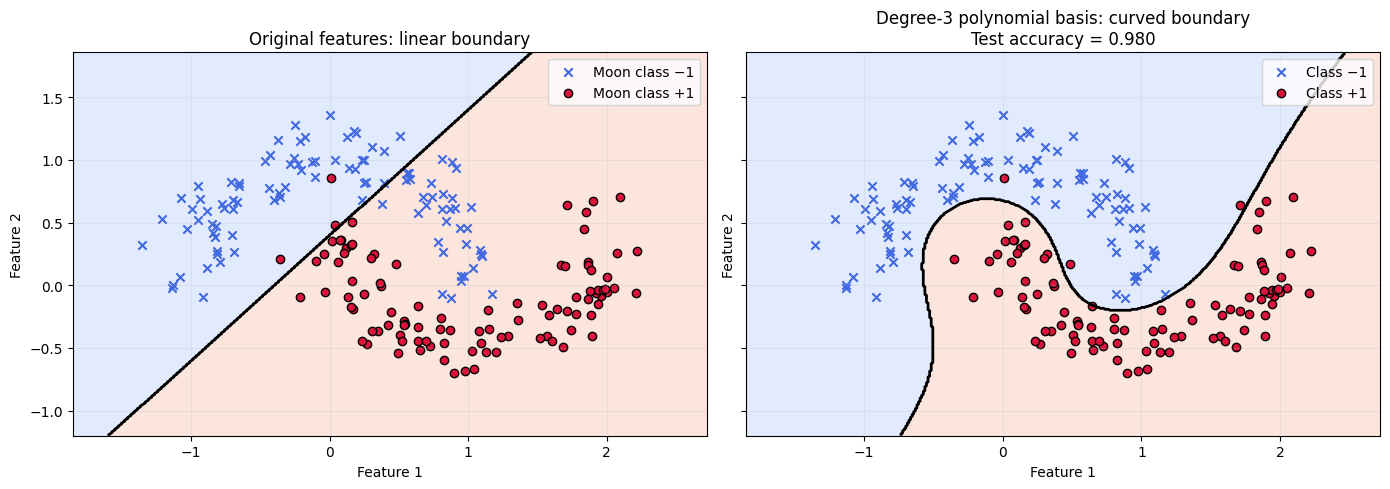

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharex=True,
    sharey=True
)

plot_classifier_regions(
    moon_model,
    X_moons,
    y_moons,
    "Original features: linear boundary",
    axes[0],
    class_names=("Moon class −1", "Moon class +1"),
)

plot_classifier_regions(
    polynomial_moon_model,
    X_moons,
    y_moons,
    (
        "Degree-3 polynomial basis: curved boundary\n"
        f"Test accuracy = {polynomial_accuracy:.3f}"
    ),
    axes[1]
)

plt.tight_layout()
plt.show()

## Student practice Option A

> The remaining code cells intentionally contain blanks. Complete the tasks in order; **Run all** will not finish successfully until every blank has been replaced.

## Task 1 — Load and inspect real classification data

The breast-cancer dataset contains 30 numerical features and a binary target. This is an educational prediction exercise, not a clinical decision tool.

Complete the function arguments so that the dataset is returned as Pandas objects. Then display:

- the first five rows of the complete frame;
- the feature-matrix shape;
- the target names;
- the count of each target class.

In [ ]:
# Replace _____ with the appropriate argument.
cancer = load_breast_cancer(_____)

display(cancer._____())
print("Feature shape:", cancer._____.shape)
print("Target names:", cancer._____)
print("Class counts:")
print(cancer._____.value_counts())

## Task 2 — Select $X$ and $y$, then split

Use all available features as `X` and the dataset target as `y`. Create a split with:

- 25% test data;
- random state 42;
- stratification using the target.

The function is given; complete its arguments.

In [ ]:
X_cancer = cancer._____
y_cancer = cancer._____

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    _____,
    _____,
    test_size=_____,
    random_state=_____,
    stratify=_____,
)

print("Training shape:", Xc_train.shape)
print("Test shape:", Xc_test.shape)

## Task 3 — Construct and train the model

Feature scales differ substantially, so construct a pipeline containing:

1. `StandardScaler()`;
2. `Perceptron` with `max_iter=1000`, `tol=1e-3`, `eta0=0.1`, and random state 42.

Complete the constructor parameters and method arguments.

In [ ]:
cancer_model = make_pipeline(
    StandardScaler(),
    Perceptron(
        max_iter=_____,
        tol=_____,
        eta0=_____,
        random_state=_____,
    ),
)

cancer_model.fit(_____, _____)
cancer_predictions = cancer_model.predict(_____)

## Task 4 — Evaluate the classifier

Calculate test accuracy and create a confusion matrix. Complete the function arguments and use the dataset's class names as display labels.

In [ ]:
test_accuracy = accuracy_score(_____, _____)
print(f"Test accuracy: {test_accuracy:.3f}")

ConfusionMatrixDisplay.from_predictions(
    _____,
    _____,
    display_labels=_____,
    cmap="Blues",
)
plt.title("Breast-cancer test confusion matrix")
plt.show()

### Written answer

Report:

1. total correct predictions;
2. total incorrect predictions;
3. which true class produced more errors;
4. why accuracy alone is insufficient for a medical dataset;
5. why this classroom model must not be treated as a clinical tool.

## Task 5 — Complete the perceptron learning rule

The Python structure is supplied. Complete only the expressions that implement the algorithm. Do not use scikit-learn inside this function.

In [ ]:
def practice_perceptron(X, y, learning_rate=0.1, epochs=20):
    w = np.zeros(_____)
    b = 0.0
    mistakes = []

    for epoch in range(epochs):
        epoch_mistakes = 0

        for xi, yi in zip(_____, _____):
            score = np.dot(_____, _____) + _____

            if _____ <= 0:
                w = w + _____
                b = b + _____
                epoch_mistakes += 1

        mistakes.append(_____)

    return w, b, np.array(mistakes)

## Task 6 - Visualizing a two-feature decision boundary

The previous model uses all 30 features, so its decision boundary cannot be displayed directly in a two-dimensional plot.

For visualization, train a second perceptron using only:

- `mean radius`;
- `mean texture`.

Convert the target from `0/1` to `-1/+1`, create a stratified train/test split and construct a pipeline containing `StandardScaler` and `Perceptron`.

Then:

1. calculate its test accuracy;
2. plot its decision regions;
3. compare its accuracy with the model that uses all 30 features.

> This is a separate visualization model. Its performance may be lower because it uses only two of the available features.

In [ ]:
visual_features = [
    "mean radius",
    "mean texture"
]

X_visual = cancer.data[_____].to_numpy()

# Convert 0/1 labels into -1/+1
y_visual = np.where(
    cancer.target.to_numpy() == _____,
    _____,
    _____
)

Xv_train, Xv_test, yv_train, yv_test = train_test_split(
    _____,
    _____,
    test_size=_____,
    random_state=_____,
    stratify=_____,
)

visual_model = make_pipeline(
    StandardScaler(),
    Perceptron(
        max_iter=_____,
        tol=_____,
        eta0=_____,
        random_state=_____,
    ),
)

visual_model.fit(
    _____,
    _____
)

visual_predictions = visual_model.predict(
    _____
)

visual_accuracy = accuracy_score(
    _____,
    _____
)

print(
    "Two-feature test accuracy:",
    round(visual_accuracy, 3)
)

fig, ax = plt.subplots(figsize=(8, 6))

plot_classifier_regions(
    visual_model,
    X_visual,
    y_visual,
    (
        "Breast-cancer classification using two features\n"
        f"Test accuracy: {visual_accuracy:.3f}"
    ),
    ax,
)

ax.set_xlabel("Mean radius")
ax.set_ylabel("Mean texture")
plt.show()

## Option B — Independent classification challenge

The next cell creates a new binary-classification dataset. Apply the complete classification workflow independently. You may refer to previous sections, but no starter code is provided.

### Requirements

1. **Inspect the data**

   - Display the shapes and class counts.
   - Visualize both classes in a labelled scatter plot.
   - State whether a linear boundary appears suitable.

2. **Prepare the data**

   - Convert the labels from `0/1` to `-1/+1`.
   - Create a stratified 75%–25% train/test split using `random_state=42`.
   - Standardize the features, fitting the scaler only on the training data.

3. **Use scikit-learn**

   Train a `Perceptron` with:

   - `max_iter=1000`
   - `tol=1e-3`
   - `eta0=0.1`
   - `random_state=42`

   Report its weights, intercept, epochs, test accuracy and confusion matrix. Plot its decision boundary.

4. **Implement it from scratch**

   Write training and prediction functions that apply the perceptron update rule. Record the number of updates in every epoch and stop when an epoch has zero updates.

   Report the final parameters, epochs, total updates and test accuracy. Plot updates against epochs.

5. **Interpret**

   Briefly compare the two implementations. Explain any differences in their coefficients or accuracy, whether the manual model converged, and what the confusion matrix reveals beyond accuracy.

### Challenge dataset: wine classification

The Wine dataset contains chemical measurements of wines produced from different cultivars.

For this challenge, we use:

- two cultivars as the binary target;
- `color_intensity` and `proline` as input features.

Each row represents one wine sample. The objective is to predict its cultivar from the two chemical measurements.

The dataset is provided below. Complete the remaining classification workflow independently.

In [ ]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

# Keep only two classes to create a binary-classification problem
binary_mask = wine.target.isin([0, 1])

# Use two features so the decision boundary can be visualized
X_challenge = wine.data.loc[
    binary_mask,
    ["color_intensity", "proline"]
].to_numpy()

y_challenge_zero_one = wine.target.loc[
    binary_mask
].to_numpy()

print("Challenge dataset loaded.")

Challenge dataset loaded.


# Homework